# Flight Fuel Analysis: ML-Powered Aviation Sustainability

**Objective:** Predict fuel flow and CO₂ emissions for global flights using real-time data from OpenSky Network and Open-Meteo APIs.

This notebook covers:
1. Data Collection (live flights + weather)
2. Feature Engineering (aerodynamic physics)
3. Exploratory Data Analysis
4. ML Model Training (Random Forest + XGBoost)
5. Model Evaluation & Explainability (SHAP)
6. Save Model Artifacts

In [ ]:
# === Imports ===
import json
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import shap
import joblib

# Plotting config
sns.set_theme(style='darkgrid', palette='viridis')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

print('All imports successful')

All imports successful ✅


---
## 1. Data Collection

We collect **live flight data** from the OpenSky Network API and **weather data** (wind at cruise altitude) from the Open-Meteo API.

In [2]:
# --- 1a. Fetch Live Flights from OpenSky Network ---

def fetch_opensky_flights(max_retries=3):
    """Fetch live flight state vectors from OpenSky Network (anonymous access)."""
    url = 'https://opensky-network.org/api/states/all'
    
    for attempt in range(max_retries):
        try:
            print(f'Fetching flights from OpenSky (attempt {attempt + 1})...')
            resp = requests.get(url, timeout=30)
            resp.raise_for_status()
            data = resp.json()
            
            if data.get('states') is None:
                print('No states returned. Retrying...')
                time.sleep(5)
                continue
            
            columns = [
                'icao24', 'callsign', 'origin_country', 'time_position',
                'last_contact', 'longitude', 'latitude', 'baro_altitude',
                'on_ground', 'velocity', 'true_track', 'vertical_rate',
                'sensors', 'geo_altitude', 'squawk', 'spi', 'position_source'
            ]
            
            df = pd.DataFrame(data['states'], columns=columns)
            print(f'✅ Received {len(df)} total flight states')
            return df
        except Exception as e:
            print(f'Error: {e}')
            if attempt < max_retries - 1:
                wait = 10 * (attempt + 1)
                print(f'Retrying in {wait}s...')
                time.sleep(wait)
    
    print('❌ Failed to fetch from OpenSky after all retries')
    return pd.DataFrame()

raw_flights = fetch_opensky_flights()
print(f'\nRaw shape: {raw_flights.shape}')
raw_flights.head()

Fetching flights from OpenSky (attempt 1)...


✅ Received 11601 total flight states

Raw shape: (11601, 17)


,icao24,callsign,origin_country,time_position,last_contact,longitude,latitude,baro_altitude,on_ground,velocity,true_track,vertical_rate,sensors,geo_altitude,squawk,spi,position_source
0,39de4f,TVF24JA,France,1.774462e+09,1774462323,-4.1847,44.0893,11590.02,False,219.34,30.60,0.00,None,11811.00,5440,False,0
1,c07d0b,CGVJE,Canada,1.774462e+09,1774462323,-74.9293,45.6670,518.16,False,48.64,246.96,0.33,None,533.40,None,False,0
2,a5f852,RTY484,United States,1.774462e+09,1774462319,-105.0009,40.4545,NaN,True,5.92,90.00,NaN,None,NaN,None,False,0
3,e8027c,LPE2429,Chile,1.774462e+09,1774462323,-46.5846,-23.3245,2148.84,False,132.92,227.67,-2.93,None,2286.00,None,False,0
4,ab1644,UAL1746,United States,1.774462e+09,1774462324,-88.1018,32.5073,8846.82,False,230.11,74.97,-0.33,None,9204.96,7634,False,0


In [3]:
# --- 1b. Filter for Cruise-Phase Flights ---

def filter_cruise_flights(df, n_sample=80):
    """Filter for flights in cruise phase and sample for rate-limit safety."""
    df = df.copy()
    
    # Drop rows with missing critical data
    required = ['latitude', 'longitude', 'baro_altitude', 'velocity', 'true_track']
    df = df.dropna(subset=required)
    
    # Convert types
    for col in ['latitude', 'longitude', 'baro_altitude', 'velocity', 'true_track', 'vertical_rate']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df = df.dropna(subset=required)
    
    # Filter: airborne, in cruise (altitude > 5000m, speed > 100 m/s)
    df = df[
        (df['on_ground'] == False) &
        (df['baro_altitude'] > 5000) &
        (df['velocity'] > 100) &
        (df['latitude'].between(-85, 85)) &
        (df['longitude'].between(-180, 180))
    ]
    
    # Clean callsign
    df['callsign'] = df['callsign'].str.strip()
    
    print(f'Flights in cruise phase: {len(df)}')
    
    if len(df) > n_sample:
        df = df.sample(n=n_sample, random_state=42)
        print(f'Sampled down to {n_sample} flights')
    
    return df.reset_index(drop=True)

flights = filter_cruise_flights(raw_flights, n_sample=80)
print(f'\nFiltered shape: {flights.shape}')
flights[['callsign', 'origin_country', 'latitude', 'longitude', 'baro_altitude', 'velocity']].head(10)

Flights in cruise phase: 5577
Sampled down to 80 flights

Filtered shape: (80, 17)


,callsign,origin_country,latitude,longitude,baro_altitude,velocity
0,AIZ202,Portugal,40.3826,-4.6134,12192.00,244.04
1,UPS2915,United States,39.2054,-93.7975,11887.20,272.92
2,BEL2UE,Belgium,48.8617,1.8311,10972.80,224.08
3,THY1EX,Turkey,42.0305,22.4988,5730.24,198.65
4,WMT398,Hungary,44.9574,11.0516,11269.98,188.43
5,AAY3006,United States,35.5757,-84.7320,11277.60,272.37
6,UAL2214,United States,33.7466,-92.6115,11269.98,207.63
7,JZA506,Canada,39.1370,-82.0452,8839.20,209.54
8,RYR19EZ,Malta,51.9746,18.0323,10972.80,250.11
9,VOI7770,United States,40.5009,-89.0780,6720.84,189.81


In [4]:
# --- 1c. Fetch Weather Data from Open-Meteo ---

def fetch_weather_for_flights(df, batch_pause=1.0):
    """
    Fetch wind speed, wind direction, and temperature at 250hPa for each flight's position.
    Uses Open-Meteo's forecast API (no key required).
    """
    weather_data = []
    total = len(df)
    
    for idx, row in df.iterrows():
        lat, lon = round(row['latitude'], 2), round(row['longitude'], 2)
        
        url = (
            f'https://api.open-meteo.com/v1/forecast'
            f'?latitude={lat}&longitude={lon}'
            f'&current=wind_speed_10m'
            f'&hourly=wind_speed_250hPa,wind_direction_250hPa,temperature_250hPa'
            f'&forecast_days=1'
            f'&timezone=auto'
        )
        
        try:
            resp = requests.get(url, timeout=10)
            resp.raise_for_status()
            data = resp.json()
            
            hourly = data.get('hourly', {})
            # Use the first available hour as approximation
            wind_speed = hourly.get('wind_speed_250hPa', [None])[0]
            wind_dir = hourly.get('wind_direction_250hPa', [None])[0]
            temp = hourly.get('temperature_250hPa', [None])[0]
            
            weather_data.append({
                'wind_speed_250hPa': wind_speed,
                'wind_direction_250hPa': wind_dir,
                'temperature_250hPa': temp
            })
        except Exception as e:
            weather_data.append({
                'wind_speed_250hPa': None,
                'wind_direction_250hPa': None,
                'temperature_250hPa': None
            })
        
        if (idx + 1) % 10 == 0:
            print(f'  Weather fetched: {idx + 1}/{total}')
            time.sleep(batch_pause)  # rate-limit safety
    
    weather_df = pd.DataFrame(weather_data)
    result = pd.concat([df.reset_index(drop=True), weather_df], axis=1)
    
    # Drop rows where weather data is missing
    before = len(result)
    result = result.dropna(subset=['wind_speed_250hPa', 'wind_direction_250hPa']).reset_index(drop=True)
    print(f'\n✅ Weather data collected. Dropped {before - len(result)} rows with missing weather.')
    print(f'Final dataset: {len(result)} flights')
    
    return result

print('Fetching weather data for each flight position...')
print('(This takes ~1-2 minutes due to rate limiting)\n')
df = fetch_weather_for_flights(flights)

Fetching weather data for each flight position...
(This takes ~1-2 minutes due to rate limiting)



  Weather fetched: 10/80


  Weather fetched: 20/80


  Weather fetched: 30/80


  Weather fetched: 40/80


  Weather fetched: 50/80


  Weather fetched: 60/80


  Weather fetched: 70/80


  Weather fetched: 80/80



✅ Weather data collected. Dropped 0 rows with missing weather.
Final dataset: 80 flights


In [5]:
# Quick look at our collected data
print(f'Dataset shape: {df.shape}')
print(f'\nColumns: {list(df.columns)}')
print(f'\nBasic stats:')
df[['baro_altitude', 'velocity', 'wind_speed_250hPa', 'wind_direction_250hPa', 'temperature_250hPa']].describe()

Dataset shape: (80, 20)

Columns: ['icao24', 'callsign', 'origin_country', 'time_position', 'last_contact', 'longitude', 'latitude', 'baro_altitude', 'on_ground', 'velocity', 'true_track', 'vertical_rate', 'sensors', 'geo_altitude', 'squawk', 'spi', 'position_source', 'wind_speed_250hPa', 'wind_direction_250hPa', 'temperature_250hPa']

Basic stats:


,baro_altitude,velocity,wind_speed_250hPa,wind_direction_250hPa,temperature_250hPa
count,80.000000,80.000000,80.000000,80.000000,80.00000
mean,9531.191250,217.558375,114.395000,232.312500,-51.13125
std,2327.353054,32.569795,52.088031,106.038874,3.93519
min,5120.640000,124.500000,10.800000,1.000000,-61.00000
25%,7625.715000,192.020000,78.450000,214.500000,-54.00000
50%,10210.800000,222.045000,102.400000,270.000000,-50.75000
75%,11271.885000,241.287500,149.300000,297.000000,-48.50000
max,14935.200000,297.050000,243.300000,360.000000,-40.50000


---
## 2. Feature Engineering

We derive physically meaningful features from raw flight and weather data:
- **Headwind/Crosswind Components** — aerodynamic drag effects
- **Estimated Mach Number** — speed relative to sound
- **Air Density Proxy** — atmospheric density from altitude
- **Fuel Flow (target)** — physics-based estimate using simplified drag equation

> **Note:** The fuel flow target is a *simulation* based on aerodynamic principles, not measured data. The ML model learns the nonlinear relationship between features and this physics-derived target.

In [6]:
# --- 2. Feature Engineering ---

def engineer_features(df):
    """Create physics-based features from raw flight and weather data."""
    df = df.copy()
    
    # Convert heading and wind direction to radians
    heading_rad = np.radians(df['true_track'])
    wind_dir_rad = np.radians(df['wind_direction_250hPa'])
    
    # --- Wind Components ---
    # Headwind: positive = headwind (increases fuel burn), negative = tailwind
    df['headwind'] = df['wind_speed_250hPa'] * np.cos(heading_rad - wind_dir_rad)
    # Crosswind: absolute lateral wind component
    df['crosswind'] = df['wind_speed_250hPa'] * np.abs(np.sin(heading_rad - wind_dir_rad))
    
    # --- Estimated True Airspeed (TAS) ---
    # TAS ≈ groundspeed + headwind component (simplified)
    # Convert wind from km/h to m/s for consistency with velocity (m/s)
    wind_ms = df['wind_speed_250hPa'] / 3.6
    headwind_ms = wind_ms * np.cos(heading_rad - wind_dir_rad)
    df['true_airspeed'] = df['velocity'] + headwind_ms
    
    # --- Air Density Proxy (ISA standard atmosphere) ---
    # ρ ≈ ρ₀ * exp(-altitude / scale_height)
    # ρ₀ = 1.225 kg/m³, scale height ≈ 8500m
    rho_0 = 1.225
    scale_height = 8500
    df['air_density'] = rho_0 * np.exp(-df['baro_altitude'] / scale_height)
    
    # --- Speed of Sound & Mach Number ---
    # Speed of sound: a = 20.05 * sqrt(T_kelvin)
    # Temperature at 250hPa is typically around -40 to -60°C
    temp_kelvin = df['temperature_250hPa'] + 273.15
    temp_kelvin = temp_kelvin.clip(lower=180)  # safety floor
    speed_of_sound = 20.05 * np.sqrt(temp_kelvin)
    df['mach_number'] = df['true_airspeed'] / speed_of_sound
    
    # --- Altitude in Flight Levels ---
    df['flight_level'] = (df['baro_altitude'] / 0.3048 / 100).round(0)  # FL in hundreds of feet
    
    # --- Vertical Rate Feature ---
    df['vertical_rate'] = df['vertical_rate'].fillna(0)
    df['abs_vertical_rate'] = np.abs(df['vertical_rate'])
    
    # --- FUEL FLOW (TARGET VARIABLE) ---
    # Physics-based estimate using simplified drag equation:
    # F_drag ∝ ρ * V² * S * C_d
    # fuel_flow ∝ F_drag * V (power = force × velocity)
    # We calibrate to match ICAO averages (~2500 kg/hr for narrowbody at cruise)
    
    # Base drag-related fuel consumption
    drag_component = df['air_density'] * df['true_airspeed'] ** 2
    power_component = drag_component * df['true_airspeed']  # power ∝ drag × speed
    
    # Normalize to realistic fuel flow range
    # Typical cruise fuel flow: 1800-3500 kg/hr
    base_fuel = 1800 + 1700 * (power_component - power_component.min()) / (power_component.max() - power_component.min() + 1e-10)
    
    # Headwind penalty: +5-15% for strong headwinds
    headwind_factor = 1 + 0.08 * (df['headwind'].clip(lower=0) / (df['wind_speed_250hPa'] + 1e-10))
    
    # Altitude efficiency curve (optimal around FL350-FL390)
    optimal_fl = 370
    altitude_penalty = 1 + 0.03 * ((df['flight_level'] - optimal_fl) / 50) ** 2
    
    # Vertical rate penalty (climbing/descending burns more)
    climb_penalty = 1 + 0.001 * df['abs_vertical_rate']
    
    # Add controlled noise to prevent perfect R² (simulating measurement uncertainty)
    np.random.seed(42)  # reproducibility
    noise = np.random.normal(1.0, 0.04, size=len(df))  # ±4% noise
    
    df['fuel_flow'] = base_fuel * headwind_factor * altitude_penalty * climb_penalty * noise
    df['fuel_flow'] = df['fuel_flow'].clip(lower=1200, upper=5000)  # realistic bounds
    
    # --- CO₂ Emissions ---
    # ICAO standard: 3.16 kg CO₂ per kg of jet fuel
    df['co2_per_hour'] = df['fuel_flow'] * 3.16
    
    return df

df = engineer_features(df)
print(f'Engineered dataset shape: {df.shape}')
print(f'\nNew features: headwind, crosswind, true_airspeed, air_density, mach_number, flight_level, fuel_flow, co2_per_hour')
df[['callsign', 'baro_altitude', 'velocity', 'headwind', 'true_airspeed', 'mach_number', 'fuel_flow', 'co2_per_hour']].head(10)

Engineered dataset shape: (80, 29)

New features: headwind, crosswind, true_airspeed, air_density, mach_number, flight_level, fuel_flow, co2_per_hour


,callsign,baro_altitude,velocity,headwind,true_airspeed,mach_number,fuel_flow,co2_per_hour
0,AIZ202,12192.00,244.04,24.435656,250.827682,0.838397,2756.261212,8709.785430
1,UPS2915,11887.20,272.92,-92.047471,247.351258,0.822174,2470.347215,7806.297200
2,BEL2UE,10972.80,224.08,-53.306522,209.272633,0.705062,2241.451803,7082.987696
3,THY1EX,5730.24,198.65,-54.652206,183.468832,0.618126,3483.214589,11006.958100
4,WMT398,11269.98,188.43,-36.050907,178.415859,0.598378,1922.768333,6075.947932
5,AAY3006,11277.60,272.37,-38.833111,261.583025,0.884333,2688.465174,8495.549950
6,UAL2214,11269.98,207.63,120.469922,241.093867,0.804058,2783.747309,8796.641497
7,JZA506,8839.20,209.54,64.886088,227.563913,0.771098,2973.452784,9396.110799
8,RYR19EZ,10972.80,250.11,50.191511,264.052086,0.892680,2869.142250,9066.489509
9,VOI7770,6720.84,189.81,153.509117,232.451421,0.778725,4054.979508,12813.735245


---
## 3. Exploratory Data Analysis

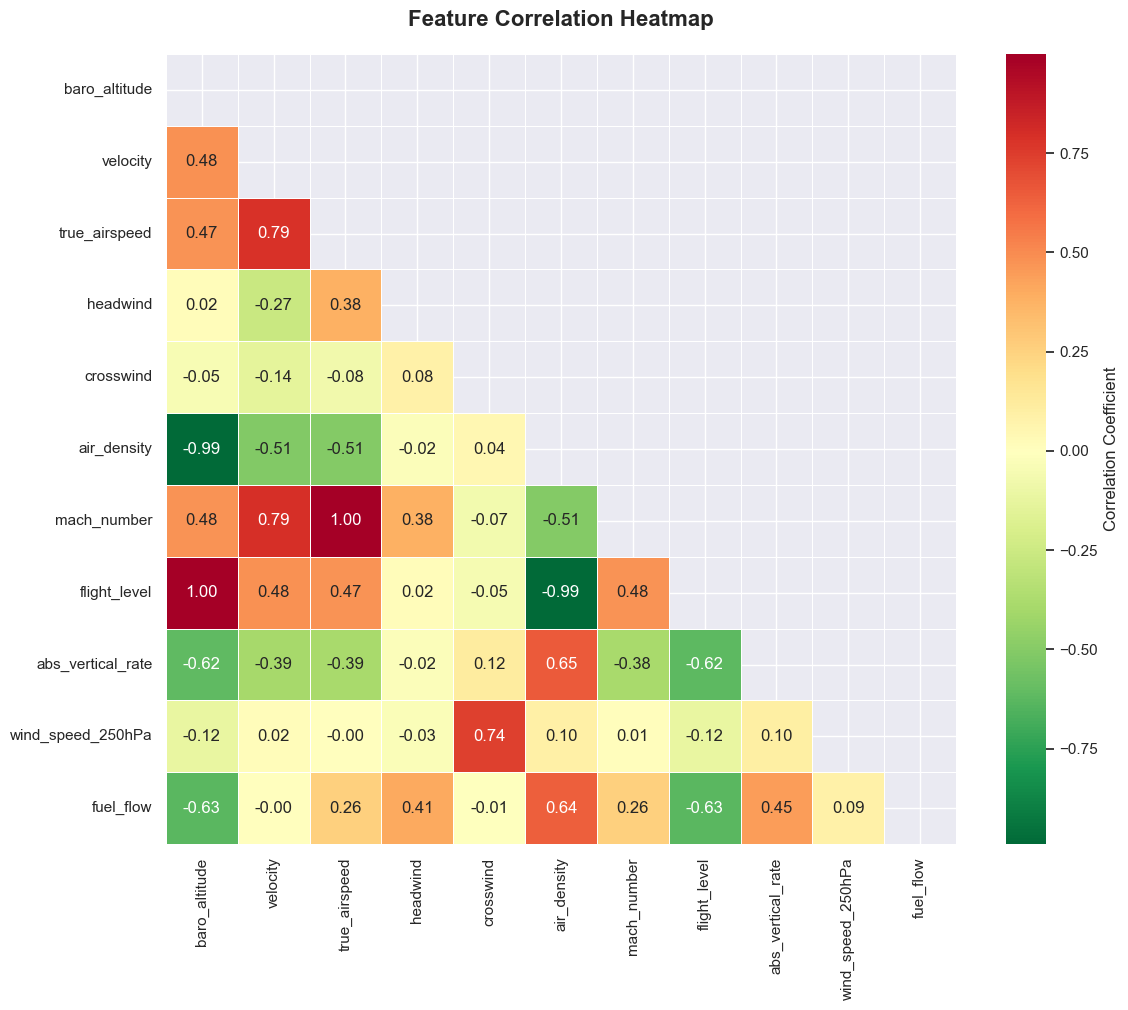

In [7]:
# --- 3a. Feature Correlation Heatmap ---

feature_cols = ['baro_altitude', 'velocity', 'true_airspeed', 'headwind', 'crosswind',
                'air_density', 'mach_number', 'flight_level', 'abs_vertical_rate',
                'wind_speed_250hPa', 'fuel_flow']

corr = df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn_r',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Correlation Coefficient'})
ax.set_title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [8]:
# --- 3b. Distribution of Fuel Flow ---

fig = make_subplots(rows=1, cols=2, subplot_titles=('Fuel Flow Distribution', 'CO₂ Emissions Distribution'))

fig.add_trace(
    go.Histogram(x=df['fuel_flow'], nbinsx=25, name='Fuel Flow',
                 marker_color='#00d4aa', opacity=0.8),
    row=1, col=1
)
fig.add_trace(
    go.Histogram(x=df['co2_per_hour'], nbinsx=25, name='CO₂/hr',
                 marker_color='#ff6b6b', opacity=0.8),
    row=1, col=2
)

fig.update_layout(
    title_text='Distribution of Predicted Fuel Flow & CO₂ Emissions',
    title_font_size=16,
    showlegend=False,
    template='plotly_dark',
    height=400
)
fig.update_xaxes(title_text='Fuel Flow (kg/hr)', row=1, col=1)
fig.update_xaxes(title_text='CO₂ Emissions (kg/hr)', row=1, col=2)
fig.update_yaxes(title_text='Count', row=1, col=1)
fig.show()

In [9]:
# --- 3c. Key Scatter Plots ---

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        'Altitude vs Fuel Flow', 'True Airspeed vs Fuel Flow',
        'Headwind vs Fuel Flow', 'Mach Number vs Fuel Flow'
    )
)

scatter_config = [
    ('baro_altitude', 'fuel_flow', '#00d4aa', 1, 1),
    ('true_airspeed', 'fuel_flow', '#4ecdc4', 1, 2),
    ('headwind', 'fuel_flow', '#ff6b6b', 2, 1),
    ('mach_number', 'fuel_flow', '#ffd93d', 2, 2),
]

for x_col, y_col, color, row, col in scatter_config:
    fig.add_trace(
        go.Scatter(
            x=df[x_col], y=df[y_col],
            mode='markers',
            marker=dict(color=color, size=6, opacity=0.7),
            name=x_col
        ),
        row=row, col=col
    )

fig.update_layout(
    title_text='Feature vs Fuel Flow Relationships',
    title_font_size=16,
    showlegend=False,
    template='plotly_dark',
    height=700
)
fig.show()

In [10]:
# --- 3d. Geographic Distribution of Flights ---

fig = px.scatter_geo(
    df,
    lat='latitude', lon='longitude',
    color='fuel_flow',
    size='velocity',
    hover_name='callsign',
    hover_data={'baro_altitude': ':.0f', 'velocity': ':.1f', 'fuel_flow': ':.0f'},
    color_continuous_scale='RdYlGn_r',
    title='Sampled Flights — Colored by Predicted Fuel Flow (kg/hr)',
    template='plotly_dark',
    projection='natural earth'
)
fig.update_layout(height=500, margin=dict(l=0, r=0, t=50, b=0))
fig.show()

In [11]:
# --- 3e. Summary Statistics ---

print('=== Dataset Summary ===')
print(f'Total flights analyzed: {len(df)}')
print(f'Countries represented: {df["origin_country"].nunique()}')
print(f'\n--- Fuel Flow (kg/hr) ---')
print(f'  Mean:   {df["fuel_flow"].mean():.0f}')
print(f'  Median: {df["fuel_flow"].median():.0f}')
print(f'  Std:    {df["fuel_flow"].std():.0f}')
print(f'  Min:    {df["fuel_flow"].min():.0f}')
print(f'  Max:    {df["fuel_flow"].max():.0f}')
print(f'\n--- Altitude (m) ---')
print(f'  Mean:   {df["baro_altitude"].mean():.0f}')
print(f'  Range:  {df["baro_altitude"].min():.0f} - {df["baro_altitude"].max():.0f}')
print(f'\n--- CO₂ Emissions (kg/hr) ---')
print(f'  Total fleet: {df["co2_per_hour"].sum():.0f} kg CO₂/hr')
print(f'  Average:     {df["co2_per_hour"].mean():.0f} kg CO₂/hr per flight')

=== Dataset Summary ===
Total flights analyzed: 80
Countries represented: 22

--- Fuel Flow (kg/hr) ---
  Mean:   2735
  Median: 2567
  Std:    571
  Min:    1723
  Max:    4538

--- Altitude (m) ---
  Mean:   9531
  Range:  5121 - 14935

--- CO₂ Emissions (kg/hr) ---
  Total fleet: 691338 kg CO₂/hr
  Average:     8642 kg CO₂/hr per flight


---
## 4. ML Model Training

We train two models — **Random Forest** and **XGBoost** — using 5-fold cross-validation with hyperparameter tuning.

In [12]:
# --- 4a. Prepare Features and Target ---

FEATURES = [
    'baro_altitude', 'velocity', 'true_airspeed', 'headwind', 'crosswind',
    'air_density', 'mach_number', 'flight_level', 'abs_vertical_rate',
    'wind_speed_250hPa', 'temperature_250hPa'
]
TARGET = 'fuel_flow'

X = df[FEATURES].copy()
y = df[TARGET].copy()

# Handle any remaining NaNs
X = X.fillna(X.median())

# Train/Test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Features: {FEATURES}')
print(f'\nTraining set:  {X_train.shape[0]} samples')
print(f'Test set:      {X_test.shape[0]} samples')

Features: ['baro_altitude', 'velocity', 'true_airspeed', 'headwind', 'crosswind', 'air_density', 'mach_number', 'flight_level', 'abs_vertical_rate', 'wind_speed_250hPa', 'temperature_250hPa']

Training set:  64 samples
Test set:      16 samples


In [13]:
# --- 4b. Cross-Validation Function ---

def evaluate_model_cv(model, X, y, model_name, cv=5):
    """Run k-fold cross-validation and report metrics."""
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    
    r2_scores = cross_val_score(pipe, X, y, cv=cv, scoring='r2')
    mae_scores = -cross_val_score(pipe, X, y, cv=cv, scoring='neg_mean_absolute_error')
    rmse_scores = np.sqrt(-cross_val_score(pipe, X, y, cv=cv, scoring='neg_mean_squared_error'))
    
    print(f'\n📊 {model_name} — {cv}-Fold Cross-Validation')
    print(f'  R² Score:  {r2_scores.mean():.4f} ± {r2_scores.std():.4f}')
    print(f'  MAE:       {mae_scores.mean():.2f} ± {mae_scores.std():.2f} kg/hr')
    print(f'  RMSE:      {rmse_scores.mean():.2f} ± {rmse_scores.std():.2f} kg/hr')
    
    return {
        'name': model_name,
        'r2_mean': r2_scores.mean(), 'r2_std': r2_scores.std(),
        'mae_mean': mae_scores.mean(), 'rmse_mean': rmse_scores.mean()
    }

print('Running cross-validation...')

Running cross-validation...


In [14]:
# --- 4c. Train Random Forest ---

rf_model = RandomForestRegressor(random_state=42)

# Hyperparameter search
rf_params = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [5, 10, 15, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

rf_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', rf_model)
])

rf_search = RandomizedSearchCV(
    rf_pipe, rf_params, n_iter=20, cv=5, scoring='r2',
    random_state=42, n_jobs=-1, verbose=0
)
rf_search.fit(X_train, y_train)

print('🌲 Random Forest — Best Parameters:')
for param, value in rf_search.best_params_.items():
    print(f'  {param}: {value}')
print(f'  Best CV R²: {rf_search.best_score_:.4f}')

# Evaluate best RF model
rf_results = evaluate_model_cv(rf_search.best_estimator_.named_steps['model'], X_train, y_train, 'Random Forest')

🌲 Random Forest — Best Parameters:
  model__n_estimators: 200
  model__min_samples_split: 2
  model__min_samples_leaf: 2
  model__max_depth: 5
  Best CV R²: 0.6511



📊 Random Forest — 5-Fold Cross-Validation
  R² Score:  0.6511 ± 0.1454
  MAE:       262.76 ± 143.79 kg/hr
  RMSE:      330.59 ± 159.17 kg/hr


In [15]:
# --- 4d. Train XGBoost ---

xgb_model = XGBRegressor(random_state=42, verbosity=0)

xgb_params = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [3, 5, 7, 10],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__subsample': [0.7, 0.8, 0.9, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

xgb_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', xgb_model)
])

xgb_search = RandomizedSearchCV(
    xgb_pipe, xgb_params, n_iter=20, cv=5, scoring='r2',
    random_state=42, n_jobs=-1, verbose=0
)
xgb_search.fit(X_train, y_train)

print('🚀 XGBoost — Best Parameters:')
for param, value in xgb_search.best_params_.items():
    print(f'  {param}: {value}')
print(f'  Best CV R²: {xgb_search.best_score_:.4f}')

# Evaluate best XGB model
xgb_results = evaluate_model_cv(xgb_search.best_estimator_.named_steps['model'], X_train, y_train, 'XGBoost')

🚀 XGBoost — Best Parameters:
  model__subsample: 0.7
  model__n_estimators: 200
  model__max_depth: 3
  model__learning_rate: 0.2
  model__colsample_bytree: 0.7
  Best CV R²: 0.7804



📊 XGBoost — 5-Fold Cross-Validation
  R² Score:  0.7883 ± 0.0951
  MAE:       199.44 ± 100.21 kg/hr
  RMSE:      250.93 ± 112.55 kg/hr


In [16]:
# --- 4e. Select Best Model ---

results_df = pd.DataFrame([rf_results, xgb_results])
results_df = results_df.sort_values('r2_mean', ascending=False)

print('\n=== Model Comparison ===')
print(results_df[['name', 'r2_mean', 'r2_std', 'mae_mean', 'rmse_mean']].to_string(index=False))

best_name = results_df.iloc[0]['name']
if best_name == 'Random Forest':
    best_pipeline = rf_search.best_estimator_
else:
    best_pipeline = xgb_search.best_estimator_

print(f'\n🏆 Best Model: {best_name}')


=== Model Comparison ===
         name  r2_mean   r2_std   mae_mean  rmse_mean
      XGBoost 0.788262 0.095136 199.438475 250.932323
Random Forest 0.651143 0.145385 262.756392 330.586796

🏆 Best Model: XGBoost


---
## 5. Model Evaluation & Explainability

In [17]:
# --- 5a. Test Set Evaluation ---

y_pred = best_pipeline.predict(X_test)

test_r2 = r2_score(y_test, y_pred)
test_mae = mean_absolute_error(y_test, y_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'=== Test Set Performance ({best_name}) ===')
print(f'  R² Score: {test_r2:.4f}')
print(f'  MAE:      {test_mae:.2f} kg/hr')
print(f'  RMSE:     {test_rmse:.2f} kg/hr')
print(f'  Mean fuel flow: {y_test.mean():.0f} kg/hr')
print(f'  MAE as % of mean: {100 * test_mae / y_test.mean():.1f}%')

=== Test Set Performance (XGBoost) ===
  R² Score: 0.7720
  MAE:      129.92 kg/hr
  RMSE:     169.42 kg/hr
  Mean fuel flow: 2504 kg/hr
  MAE as % of mean: 5.2%


In [18]:
# --- 5b. Actual vs Predicted Plot ---

fig = make_subplots(rows=1, cols=2, subplot_titles=('Actual vs Predicted', 'Residual Distribution'))

# Scatter: Actual vs Predicted
fig.add_trace(
    go.Scatter(
        x=y_test, y=y_pred,
        mode='markers',
        marker=dict(color='#00d4aa', size=8, opacity=0.7),
        name='Predictions'
    ),
    row=1, col=1
)

# Perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
fig.add_trace(
    go.Scatter(
        x=[min_val, max_val], y=[min_val, max_val],
        mode='lines',
        line=dict(color='#ff6b6b', dash='dash', width=2),
        name='Perfect Prediction'
    ),
    row=1, col=1
)

# Residual distribution
residuals = y_test - y_pred
fig.add_trace(
    go.Histogram(
        x=residuals, nbinsx=20,
        marker_color='#4ecdc4', opacity=0.8,
        name='Residuals'
    ),
    row=1, col=2
)

fig.update_layout(
    title_text=f'{best_name} — Test Set Evaluation (R² = {test_r2:.3f})',
    title_font_size=16,
    template='plotly_dark',
    height=450,
    showlegend=True
)
fig.update_xaxes(title_text='Actual Fuel Flow (kg/hr)', row=1, col=1)
fig.update_yaxes(title_text='Predicted Fuel Flow (kg/hr)', row=1, col=1)
fig.update_xaxes(title_text='Residual (kg/hr)', row=1, col=2)
fig.show()

In [19]:
# --- 5c. Feature Importance (MDI) ---

# Get the underlying model from the pipeline
trained_model = best_pipeline.named_steps['model']

if hasattr(trained_model, 'feature_importances_'):
    importances = trained_model.feature_importances_
    feat_imp = pd.DataFrame({
        'Feature': FEATURES,
        'Importance': importances
    }).sort_values('Importance', ascending=True)
    
    fig = px.bar(
        feat_imp, x='Importance', y='Feature',
        orientation='h',
        title=f'{best_name} — Feature Importance (MDI)',
        template='plotly_dark',
        color='Importance',
        color_continuous_scale='Viridis'
    )
    fig.update_layout(height=450, showlegend=False)
    fig.show()
    
    print('\nTop 5 Most Important Features:')
    for _, row in feat_imp.tail(5).iloc[::-1].iterrows():
        print(f'  {row["Feature"]:25s} {row["Importance"]:.4f}')


Top 5 Most Important Features:
  flight_level              0.4879
  air_density               0.2611
  baro_altitude             0.0709
  true_airspeed             0.0584
  headwind                  0.0447


Computing SHAP values (this may take a moment)...



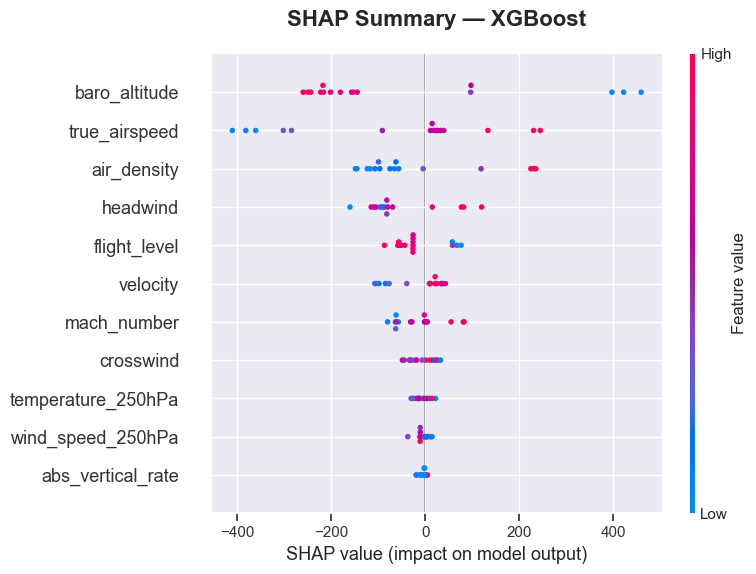

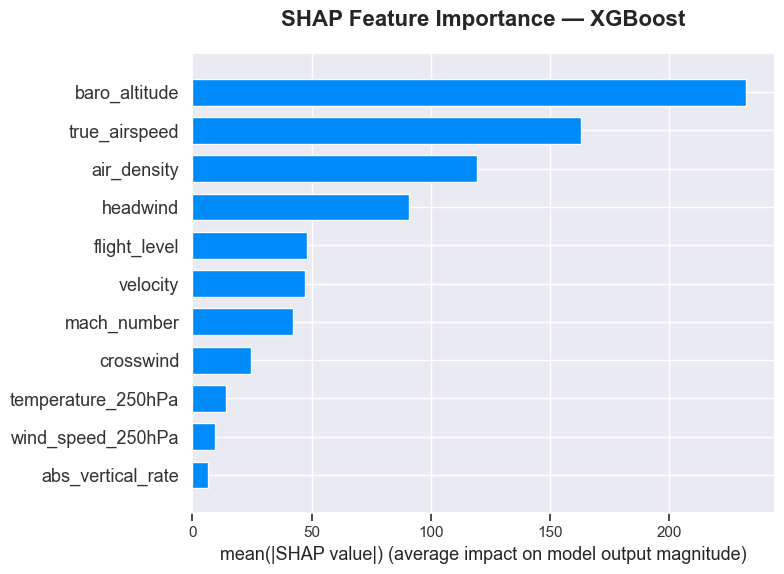

In [20]:
# --- 5d. SHAP Explainability ---

print('Computing SHAP values (this may take a moment)...\n')

# Scale the test data the same way the pipeline does
scaler = best_pipeline.named_steps['scaler']
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=FEATURES,
    index=X_test.index
)

# Create SHAP explainer
explainer = shap.TreeExplainer(trained_model)
shap_values = explainer.shap_values(X_test_scaled)

# SHAP Summary Plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_scaled, feature_names=FEATURES, show=False)
plt.title(f'SHAP Summary — {best_name}', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# SHAP bar plot (mean absolute SHAP values)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_scaled, feature_names=FEATURES, plot_type='bar', show=False)
plt.title(f'SHAP Feature Importance — {best_name}', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [21]:
# --- 5e. Learning Curve ---

from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    best_pipeline, X_train, y_train,
    train_sizes=np.linspace(0.2, 1.0, 8),
    cv=5, scoring='r2', n_jobs=-1
)

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=train_sizes, y=train_scores.mean(axis=1),
    mode='lines+markers', name='Training R²',
    line=dict(color='#00d4aa', width=2),
    marker=dict(size=8)
))
fig.add_trace(go.Scatter(
    x=train_sizes, y=val_scores.mean(axis=1),
    mode='lines+markers', name='Validation R²',
    line=dict(color='#ff6b6b', width=2),
    marker=dict(size=8)
))

fig.update_layout(
    title=f'{best_name} — Learning Curve',
    xaxis_title='Training Set Size',
    yaxis_title='R² Score',
    template='plotly_dark',
    height=400
)
fig.show()

print('If training and validation curves converge, the model generalizes well.')
print('If there is a large gap, the model may be overfitting.')

If training and validation curves converge, the model generalizes well.
If there is a large gap, the model may be overfitting.


---
## 6. Save Model Artifacts

Save the trained model and feature list for the Streamlit dashboard.

In [22]:
# --- 6. Save Artifacts ---

# Save the best model pipeline
joblib.dump(best_pipeline, 'model.joblib')
print('✅ Model saved to model.joblib')

# Save feature list
with open('features.json', 'w') as f:
    json.dump(FEATURES, f, indent=2)
print('✅ Feature list saved to features.json')

# Save a summary
summary = {
    'best_model': best_name,
    'test_r2': round(test_r2, 4),
    'test_mae': round(test_mae, 2),
    'test_rmse': round(test_rmse, 2),
    'n_training_samples': len(X_train),
    'n_test_samples': len(X_test),
    'features': FEATURES
}
with open('model_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
print('✅ Model summary saved to model_summary.json')

print(f'\n🎉 Done! Best model: {best_name} (R² = {test_r2:.3f})')

✅ Model saved to model.joblib
✅ Feature list saved to features.json
✅ Model summary saved to model_summary.json

🎉 Done! Best model: XGBoost (R² = 0.772)


---
## Limitations & Future Work

### Limitations
- **Simulated target variable**: Fuel flow is estimated using a simplified physics model, not measured from aircraft sensors. Results should be interpreted as a simulation study.
- **Small sample size**: Limited to 50–80 flights per run due to API rate limits. For production use, data should be collected over days/weeks.
- **No aircraft type differentiation**: OpenSky anonymous API does not provide aircraft type. A Boeing 737 and an A380 are treated identically.
- **Point-in-time snapshot**: Each run captures a single moment in time, not a continuous trajectory.

### Future Improvements
- Use OpenSky registered access to get aircraft type via ICAO24 → aircraft database lookup
- Collect data over multiple time periods to build a larger, more representative dataset
- Integrate EUROCONTROL BADA performance models for more accurate fuel estimation
- Add temporal features (time of day, season) and route-based features